In [ ]:
# Regresión logística binaria - Videojuegos

En este notebook se presenta el modelo de **regresión logística binaria** en dos escenarios:

1. **Datos sintéticos**: usados en la fase exploratoria para validar el comportamiento del modelo.
2. **Datos reales**: usados en la fase final, cargados desde PostgreSQL.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler

In [ ]:
## Parte A. Regresión logística binaria con datos sintéticos

In [2]:
df = pd.read_csv("../data/videojuegos_sinteticos.csv")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000, 10)


,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
0,2021,57.66,45.80,20.71,25.16,16.06,59.39,10,2921,50.00
1,2018,66.93,51.19,50.60,12.59,21.77,24.41,6,1667,51.68
2,2025,59.16,26.25,37.40,9.18,14.66,0.66,6,1090,50.00
3,2022,72.84,38.65,15.34,9.54,9.44,10.19,3,1079,53.04
4,2019,76.17,54.53,113.23,14.37,63.59,39.15,9,2816,64.44


In [3]:
umbral = 65
df["rating_bin"] = (df["rating"] >= umbral).astype(int)

print("Variable binaria creada correctamente")
print("\nDefinición:")
print("1 = rating alto (>= 65)")
print("0 = rating menor a 65")

print("\nConteo por clase:")
print(df["rating_bin"].value_counts().sort_index())

print("\nProporción por clase:")
print(df["rating_bin"].value_counts(normalize=True).sort_index().round(4))

Variable binaria creada correctamente

Definición:
1 = rating alto (>= 65)
0 = rating menor a 65

Conteo por clase:
rating_bin
0    814
1    186
Name: count, dtype: int64

Proporción por clase:
rating_bin
0    0.814
1    0.186
Name: proportion, dtype: float64


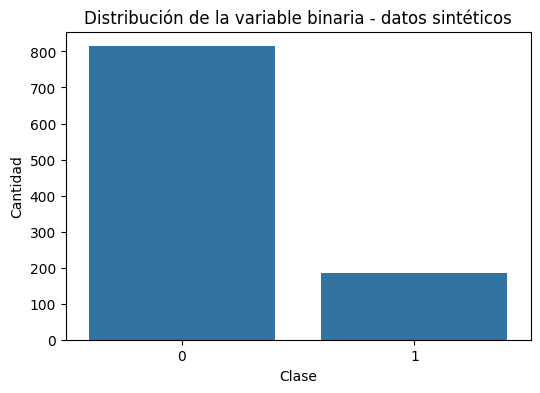

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating_bin", data=df)
plt.title("Distribución de la variable binaria - datos sintéticos")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [6]:
X_bin = df[[
    "metascore",
    "price_usd",
    "hours_gameplay",
    "social_hype",
    "discount_pct",
    "bugs_reported",
    "rating_count"
]]

y_bin = df["rating_bin"]

print("Variables independientes:")
print(X_bin.columns.tolist())
print("\nVariable dependiente:")
print("rating_bin")
print("\nForma de X:", X_bin.shape)
print("Forma de y:", y_bin.shape)

Variables independientes:
['metascore', 'price_usd', 'hours_gameplay', 'social_hype', 'discount_pct', 'bugs_reported', 'rating_count']

Variable dependiente:
rating_bin

Forma de X: (1000, 7)
Forma de y: (1000,)


In [7]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print("Entrenamiento X:", X_train_b.shape)
print("Prueba X:", X_test_b.shape)
print("Entrenamiento y:", y_train_b.shape)
print("Prueba y:", y_test_b.shape)

print("\nDistribución entrenamiento:")
print(y_train_b.value_counts(normalize=True).sort_index().round(4))

print("\nDistribución prueba:")
print(y_test_b.value_counts(normalize=True).sort_index().round(4))

Entrenamiento X: (800, 7)
Prueba X: (200, 7)
Entrenamiento y: (800,)
Prueba y: (200,)

Distribución entrenamiento:
rating_bin
0    0.8138
1    0.1862
Name: proportion, dtype: float64

Distribución prueba:
rating_bin
0    0.815
1    0.185
Name: proportion, dtype: float64


In [8]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_b, y_train_b)

y_pred_log = log_model.predict(X_test_b)
y_prob_log = log_model.predict_proba(X_test_b)[:, 1]

print("Primeras 10 probabilidades de clase 1:")
print(y_prob_log[:10])

print("\nPrimeras 10 clases predichas:")
print(y_pred_log[:10])

Primeras 10 probabilidades de clase 1:
[5.86778599e-02 9.86055071e-08 1.41531750e-02 6.99079810e-03
 3.50101904e-03 2.17840119e-03 1.46779668e-01 3.95891696e-02
 3.11827733e-04 2.16267608e-03]

Primeras 10 clases predichas:
[0 0 0 0 0 0 0 0 0 0]


In [9]:
acc_log = accuracy_score(y_test_b, y_pred_log)
prec_log = precision_score(y_test_b, y_pred_log, zero_division=0)
rec_log = recall_score(y_test_b, y_pred_log, zero_division=0)
f1_log = f1_score(y_test_b, y_pred_log, zero_division=0)

print("REGRESIÓN LOGÍSTICA BINARIA - MODELO BASE")
print("Accuracy:", round(acc_log, 4))
print("Precision:", round(prec_log, 4))
print("Recall:", round(rec_log, 4))
print("F1-score:", round(f1_log, 4))

REGRESIÓN LOGÍSTICA BINARIA - MODELO BASE
Accuracy: 0.945
Precision: 0.8824
Recall: 0.8108
F1-score: 0.8451


Matriz de confusión:
[[159   4]
 [  7  30]]


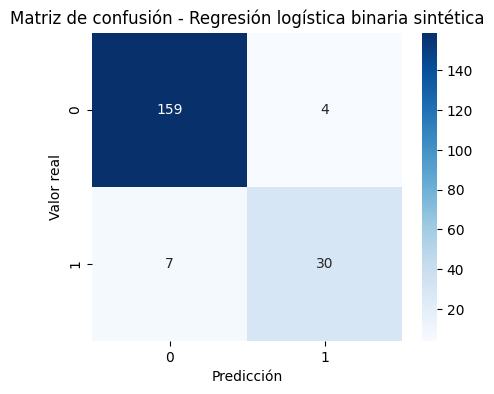

In [10]:
cm_log = confusion_matrix(y_test_b, y_pred_log)
print("Matriz de confusión:")
print(cm_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión logística binaria sintética")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [11]:
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train_b, y_train_b)

print("Distribución después de oversampling:")
print(y_train_over.value_counts().sort_index())

print("\nProporción después de oversampling:")
print(y_train_over.value_counts(normalize=True).sort_index().round(4))

Distribución después de oversampling:
rating_bin
0    651
1    651
Name: count, dtype: int64

Proporción después de oversampling:
rating_bin
0    0.5
1    0.5
Name: proportion, dtype: float64


In [12]:
log_model_over = LogisticRegression(max_iter=1000, random_state=42)
log_model_over.fit(X_train_over, y_train_over)

y_pred_log_over = log_model_over.predict(X_test_b)
y_prob_log_over = log_model_over.predict_proba(X_test_b)[:, 1]

In [13]:
acc_log_over = accuracy_score(y_test_b, y_pred_log_over)
prec_log_over = precision_score(y_test_b, y_pred_log_over, zero_division=0)
rec_log_over = recall_score(y_test_b, y_pred_log_over, zero_division=0)
f1_log_over = f1_score(y_test_b, y_pred_log_over, zero_division=0)

print("REGRESIÓN LOGÍSTICA + OVERSAMPLING")
print("Accuracy:", round(acc_log_over, 4))
print("Precision:", round(prec_log_over, 4))
print("Recall:", round(rec_log_over, 4))
print("F1-score:", round(f1_log_over, 4))

REGRESIÓN LOGÍSTICA + OVERSAMPLING
Accuracy: 0.945
Precision: 0.7826
Recall: 0.973
F1-score: 0.8675


Matriz de confusión:
[[153  10]
 [  1  36]]


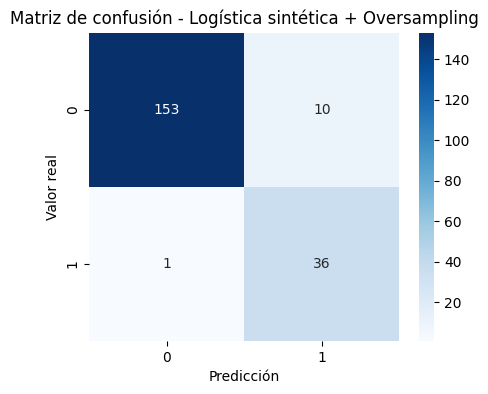

In [14]:
cm_log_over = confusion_matrix(y_test_b, y_pred_log_over)
print("Matriz de confusión:")
print(cm_log_over)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_over, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Logística sintética + Oversampling")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [15]:
comparacion_binaria_sintetica = pd.DataFrame({
    "Modelo": ["Logística base", "Logística + Oversampling"],
    "Accuracy": [acc_log, acc_log_over],
    "Precision": [prec_log, prec_log_over],
    "Recall": [rec_log, rec_log_over],
    "F1": [f1_log, f1_log_over]
})

comparacion_binaria_sintetica.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Logística base,0.945,0.8824,0.8108,0.8451
1,Logística + Oversampling,0.945,0.7826,0.9730,0.8675


In [16]:
## Parte B. Regresión logística binaria con datos reales desde PostgreSQL

In [17]:
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos


In [18]:
from scripts.database import engine, test_connection

print("Conexión correcta:", test_connection())

Conexión correcta: True


In [19]:
query = "SELECT * FROM juegos_csv"
df_real = pd.read_sql(query, engine)

print("Dimensiones:", df_real.shape)
df_real.head()

Dimensiones: (99, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [20]:
df_model = df_real.copy()

df_model["fecha_lanzamiento"] = pd.to_datetime(
    df_model["fecha_lanzamiento"],
    unit="s",
    errors="coerce"
)

df_model["release_year"] = df_model["fecha_lanzamiento"].dt.year

df_model["genre_count"] = (
    df_model["generos"]
    .fillna("")
    .apply(lambda x: len([g for g in str(x).split(",") if g.strip()]))
)

df_model["platform_count"] = (
    df_model["plataformas"]
    .fillna("")
    .apply(lambda x: len([p for p in str(x).split(",") if p.strip()]))
)

df_model["title_length"] = df_model["nombre"].fillna("").str.len()

print("Dimensiones antes de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones antes de limpiar: (99, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [21]:
df_model = df_model.dropna(subset=["rating", "rating_count", "release_year"]).copy()

print("Dimensiones después de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones después de limpiar: (42, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [22]:
umbral = 65
df_model["rating_bin"] = (df_model["rating"] >= umbral).astype(int)

print("Conteo por clase:")
print(df_model["rating_bin"].value_counts().sort_index())

print("\nProporción por clase:")
print(df_model["rating_bin"].value_counts(normalize=True).sort_index().round(4))

Conteo por clase:
rating_bin
0     8
1    34
Name: count, dtype: int64

Proporción por clase:
rating_bin
0    0.1905
1    0.8095
Name: proportion, dtype: float64


In [23]:
features_real = [
    "release_year",
    "rating_count",
    "genre_count",
    "platform_count",
    "title_length"
]

X_real_bin = df_model[features_real]
y_real_bin = df_model["rating_bin"]

print("X_real_bin:", X_real_bin.shape)
print("y_real_bin:", y_real_bin.shape)
print(y_real_bin.value_counts().sort_index())

X_real_bin: (42, 5)
y_real_bin: (42,)
rating_bin
0     8
1    34
Name: count, dtype: int64


In [24]:
X_train_real_bin, X_test_real_bin, y_train_real_bin, y_test_real_bin = train_test_split(
    X_real_bin, y_real_bin, test_size=0.2, random_state=42, stratify=y_real_bin
)

print("Entrenamiento X:", X_train_real_bin.shape)
print("Prueba X:", X_test_real_bin.shape)

print("\nDistribución entrenamiento:")
print(y_train_real_bin.value_counts().sort_index())

print("\nDistribución prueba:")
print(y_test_real_bin.value_counts().sort_index())

Entrenamiento X: (33, 5)
Prueba X: (9, 5)

Distribución entrenamiento:
rating_bin
0     6
1    27
Name: count, dtype: int64

Distribución prueba:
rating_bin
0    2
1    7
Name: count, dtype: int64


In [25]:
log_real = LogisticRegression(max_iter=1000, random_state=42)
log_real.fit(X_train_real_bin, y_train_real_bin)

y_pred_log_real = log_real.predict(X_test_real_bin)
y_prob_log_real = log_real.predict_proba(X_test_real_bin)[:, 1]

In [26]:
acc_log_real = accuracy_score(y_test_real_bin, y_pred_log_real)
prec_log_real = precision_score(y_test_real_bin, y_pred_log_real, zero_division=0)
rec_log_real = recall_score(y_test_real_bin, y_pred_log_real, zero_division=0)
f1_log_real = f1_score(y_test_real_bin, y_pred_log_real, zero_division=0)

print("REGRESIÓN LOGÍSTICA BINARIA - DATOS REALES")
print("Accuracy:", round(acc_log_real, 4))
print("Precision:", round(prec_log_real, 4))
print("Recall:", round(rec_log_real, 4))
print("F1-score:", round(f1_log_real, 4))

REGRESIÓN LOGÍSTICA BINARIA - DATOS REALES
Accuracy: 0.8889
Precision: 0.875
Recall: 1.0
F1-score: 0.9333


[[1 1]
 [0 7]]


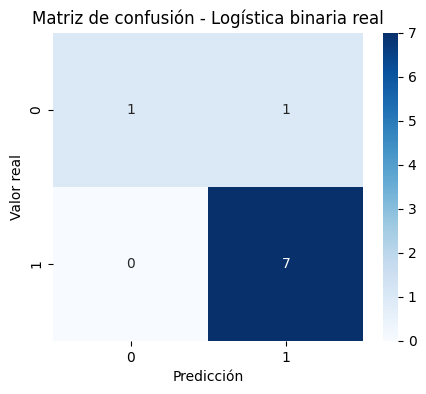

In [27]:
cm_log_real = confusion_matrix(y_test_real_bin, y_pred_log_real)
print(cm_log_real)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_real, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Logística binaria real")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [28]:
ros_real = RandomOverSampler(random_state=42)
X_train_real_over, y_train_real_over = ros_real.fit_resample(X_train_real_bin, y_train_real_bin)

print("Distribución después de oversampling:")
print(y_train_real_over.value_counts().sort_index())

print("\nProporción después de oversampling:")
print(y_train_real_over.value_counts(normalize=True).sort_index().round(4))

Distribución después de oversampling:
rating_bin
0    27
1    27
Name: count, dtype: int64

Proporción después de oversampling:
rating_bin
0    0.5
1    0.5
Name: proportion, dtype: float64


In [29]:
log_real_over = LogisticRegression(max_iter=1000, random_state=42)
log_real_over.fit(X_train_real_over, y_train_real_over)

y_pred_log_real_over = log_real_over.predict(X_test_real_bin)
y_prob_log_real_over = log_real_over.predict_proba(X_test_real_bin)[:, 1]

In [30]:
acc_log_real_over = accuracy_score(y_test_real_bin, y_pred_log_real_over)
prec_log_real_over = precision_score(y_test_real_bin, y_pred_log_real_over, zero_division=0)
rec_log_real_over = recall_score(y_test_real_bin, y_pred_log_real_over, zero_division=0)
f1_log_real_over = f1_score(y_test_real_bin, y_pred_log_real_over, zero_division=0)

print("REGRESIÓN LOGÍSTICA REAL + OVERSAMPLING")
print("Accuracy:", round(acc_log_real_over, 4))
print("Precision:", round(prec_log_real_over, 4))
print("Recall:", round(rec_log_real_over, 4))
print("F1-score:", round(f1_log_real_over, 4))

REGRESIÓN LOGÍSTICA REAL + OVERSAMPLING
Accuracy: 0.7778
Precision: 0.8571
Recall: 0.8571
F1-score: 0.8571


[[1 1]
 [1 6]]


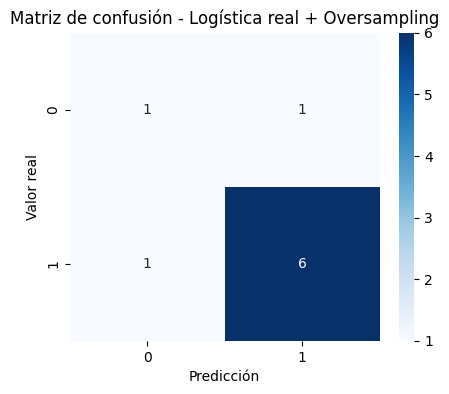

In [31]:
cm_log_real_over = confusion_matrix(y_test_real_bin, y_pred_log_real_over)
print(cm_log_real_over)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_real_over, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Logística real + Oversampling")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [32]:
comparacion_binaria_real = pd.DataFrame({
    "Modelo": ["Logística binaria real", "Logística real + Oversampling"],
    "Accuracy": [acc_log_real, acc_log_real_over],
    "Precision": [prec_log_real, prec_log_real_over],
    "Recall": [rec_log_real, rec_log_real_over],
    "F1": [f1_log_real, f1_log_real_over]
})

comparacion_binaria_real.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Logística binaria real,0.8889,0.8750,1.0000,0.9333
1,Logística real + Oversampling,0.7778,0.8571,0.8571,0.8571


In [ ]:
# Conclusión

En este notebook se aplicó el mismo modelo de **regresión logística binaria** en dos contextos:

- **Datos sintéticos**, usados en la etapa exploratoria para validar el comportamiento del modelo.
- **Datos reales**, cargados desde PostgreSQL, usados en la etapa final del proyecto.

En ambos casos se construyó la variable `rating_bin` para clasificar videojuegos en dos clases.  
También se comparó el modelo base frente a una versión con **oversampling**, con el fin de analizar el efecto del balanceo de clases.

Los resultados con datos reales deben interpretarse con cautela, ya que la muestra disponible fue más pequeña y específica que la sintética.